# Análisis Económico con Datos del Banco Mundial

Este notebook integra el flujo completo del Proyecto Integrador de Lenguaje de Programación II. Utiliza una arquitectura orientada a objetos para:
1. **Adquirir datos** desde la API del Banco Mundial mediante solicitudes HTTP (`APIEconomia`).
2. **Limpiar y procesar** la información con Pandas y Expresiones Regulares (`ProcesadorEconomico`).
3. **Visualizar** la evolución e interrelación de las variables económicas (`VisualizadorEconomico`).

### Configuración e Importación de Módulos

In [1]:
import os
import sys

# Cambiamos el directorio de trabajo al raíz del proyecto si estamos en la carpeta 'notebooks'
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

sys.path.append(os.getcwd())

from src.api_economia import APIEconomia
from src.procesador import ProcesadorEconomico
from src.visualizador import VisualizadorEconomico

print("Directorio de trabajo actual:", os.getcwd())
print("Módulos importados correctamente.")

Directorio de trabajo actual: c:\Users\jfabi\Desktop\final lp chalan
Módulos importados correctamente.


## 1. Adquisición de datos

Consultamos la API del Banco Mundial para los siguientes países:
- **Perú (PE)**
- **Chile (CL)**
- **Colombia (CO)**
- **Brasil (BR)**

Y los indicadores económicos:
- **PIB a precios actuales en USD**: `NY.GDP.MKTP.CD`
- **Inflación, precios al consumidor (% anual)**: `FP.CPI.TOTL.ZG`

In [2]:
api = APIEconomia()
paises = ["PE", "CL", "CO", "BR"]
indicador_pib = "NY.GDP.MKTP.CD"
indicador_inflacion = "FP.CPI.TOTL.ZG"

rutas_json = []

# Descargar y almacenar por separado los datasets para demostrar el uso de concatenación
for pais in paises:
    for ind, nombre in [(indicador_pib, "pib"), (indicador_inflacion, "inflacion")]:
        try:
            print(f"Descargando {nombre} para {pais}...")
            datos = api.obtener_datos(pais, ind, anio_inicio=2010, anio_fin=2023)
            ruta = api.guardar_json(datos, f"{pais.lower()}_{nombre}.json")
            rutas_json.append(ruta)
        except Exception as e:
            print(f"Error con {pais} - {nombre}: {e}")

print("\nArchivos JSON crudos guardados:", rutas_json)

Descargando pib para PE...
Archivo guardado en: data/crudo\pe_pib.json
Descargando inflacion para PE...
Archivo guardado en: data/crudo\pe_inflacion.json
Descargando pib para CL...
Archivo guardado en: data/crudo\cl_pib.json
Descargando inflacion para CL...
Archivo guardado en: data/crudo\cl_inflacion.json
Descargando pib para CO...
Archivo guardado en: data/crudo\co_pib.json
Descargando inflacion para CO...
Archivo guardado en: data/crudo\co_inflacion.json
Descargando pib para BR...
Archivo guardado en: data/crudo\br_pib.json
Descargando inflacion para BR...
Archivo guardado en: data/crudo\br_inflacion.json

Archivos JSON crudos guardados: ['data/crudo\\pe_pib.json', 'data/crudo\\pe_inflacion.json', 'data/crudo\\cl_pib.json', 'data/crudo\\cl_inflacion.json', 'data/crudo\\co_pib.json', 'data/crudo\\co_inflacion.json', 'data/crudo\\br_pib.json', 'data/crudo\\br_inflacion.json']


## 2. Limpieza y Procesamiento de Datos

Instanciamos `ProcesadorEconomico` para unir todos los archivos JSON descargados, aplicar limpieza de tipos con expresiones regulares y calcular métricas adicionales (como categorización del nivel de inflación y crecimiento).

In [3]:
procesador = ProcesadorEconomico()

# Cargar los archivos JSON a DataFrames
lista_dfs = []
for ruta in rutas_json:
    if os.path.exists(ruta):
        df_cargado = procesador.cargar_datos(ruta)
        lista_dfs.append(df_cargado)

# Unir datasets concatenándolos
df_unido = procesador.unir_datasets(lista_dfs)
print(f"Datasets unidos. Total de filas antes de limpiar: {len(df_unido)}")

# Limpieza, conversión de tipos de datos y ordenamiento
df_limpio = procesador.limpiar_y_transformar()
print(f"Datos limpios. Total de filas después de limpiar: {len(df_limpio)}")
df_limpio.head()

Datasets unidos. Total de filas antes de limpiar: 112
Datos limpios. Total de filas después de limpiar: 112


,pais,indicador,fecha_original,valor,anio
111,Brasil,"Inflación, precios al consumidor (% anual)",2010,5.038727,2010
110,Brasil,"Inflación, precios al consumidor (% anual)",2011,6.636450,2011
109,Brasil,"Inflación, precios al consumidor (% anual)",2012,5.403499,2012
108,Brasil,"Inflación, precios al consumidor (% anual)",2013,6.204311,2013
107,Brasil,"Inflación, precios al consumidor (% anual)",2014,6.329040,2014


## 3. Análisis Estadístico y Exportación

Calculamos las estadísticas agrupadas (media, mínimo, máximo) y aplicamos la lógica de categorización de la inflación.

In [4]:
# Calcular métricas y clasificar inflación
resumen = procesador.calcular_estadisticas()

# Exportar a CSV para el visualizador
ruta_csv = procesador.exportar_limpio("data/procesado/datos_limpios.csv")
print(f"Datos limpios guardados en: {ruta_csv}")

print("\n--- Resumen Estadístico Agrupado ---")
resumen.head(10)

Datos limpios guardados en: data/procesado/datos_limpios.csv

--- Resumen Estadístico Agrupado ---


,pais,indicador,mean,max,min
0,Brasil,"Inflación, precios al consumidor (% anual)",5.972312e+00,9.280106e+00,3.211768e+00
1,Brasil,PIB (US$ a precios actuales),2.068610e+12,2.616157e+12,1.476107e+12
2,Chile,"Inflación, precios al consumidor (% anual)",4.026667e+00,1.164387e+01,1.410711e+00
3,Chile,PIB (US$ a precios actuales),2.729014e+11,3.355181e+11,2.170512e+11
4,Colombia,"Inflación, precios al consumidor (% anual)",4.663442e+00,1.173590e+01,2.016992e+00
5,Colombia,PIB (US$ a precios actuales),3.286855e+11,3.820937e+11,2.703483e+11
6,Perú,"Inflación, precios al consumidor (% anual)",3.533109e+00,8.333706e+00,1.509154e+00
7,Perú,PIB (US$ a precios actuales),2.070226e+11,2.669587e+11,1.475276e+11


## 4. Visualización de Información

Instanciamos `VisualizadorEconomico` indicando la ruta del archivo CSV exportado y la carpeta de destino. Generaremos 4 tipos de gráficos:

In [5]:
visualizador = VisualizadorEconomico(ruta_csv="data/procesado/datos_limpios.csv", carpeta_salida="output/")

# Cargar datos al visualizador y validar columnas
visualizador.cargar_datos()

# Generar los gráficos de forma local y guardar las rutas
ruta_lineas = visualizador.grafico_lineas(pais="Perú", indicador="PIB", anio_inicio=2010, anio_fin=2023)
ruta_barras = visualizador.grafico_barras(indicador="Inflación", anio=2022)
ruta_dispersion = visualizador.grafico_dispersion(indicador_x="PIB", indicador_y="Inflación", anio=2022)
ruta_pastel = visualizador.grafico_pastel(anio=2022)

print("Gráficos generados exitosamente.")

--- Datos Cargados Exitosamente ---
Gráfico de barras guardado en: output/barras_inflación_2022.png
Gráfico de dispersión guardado en: output/dispersion_pib_vs_inflación_2022.png
Gráfico de pastel de inflación guardado en: output/pastel_inflacion_2022.png
Gráficos generados exitosamente.


## 5. Visualización Directa de Resultados

Mostramos en pantalla las imágenes resultantes.

1. Evolución del PIB en el Perú (Líneas)


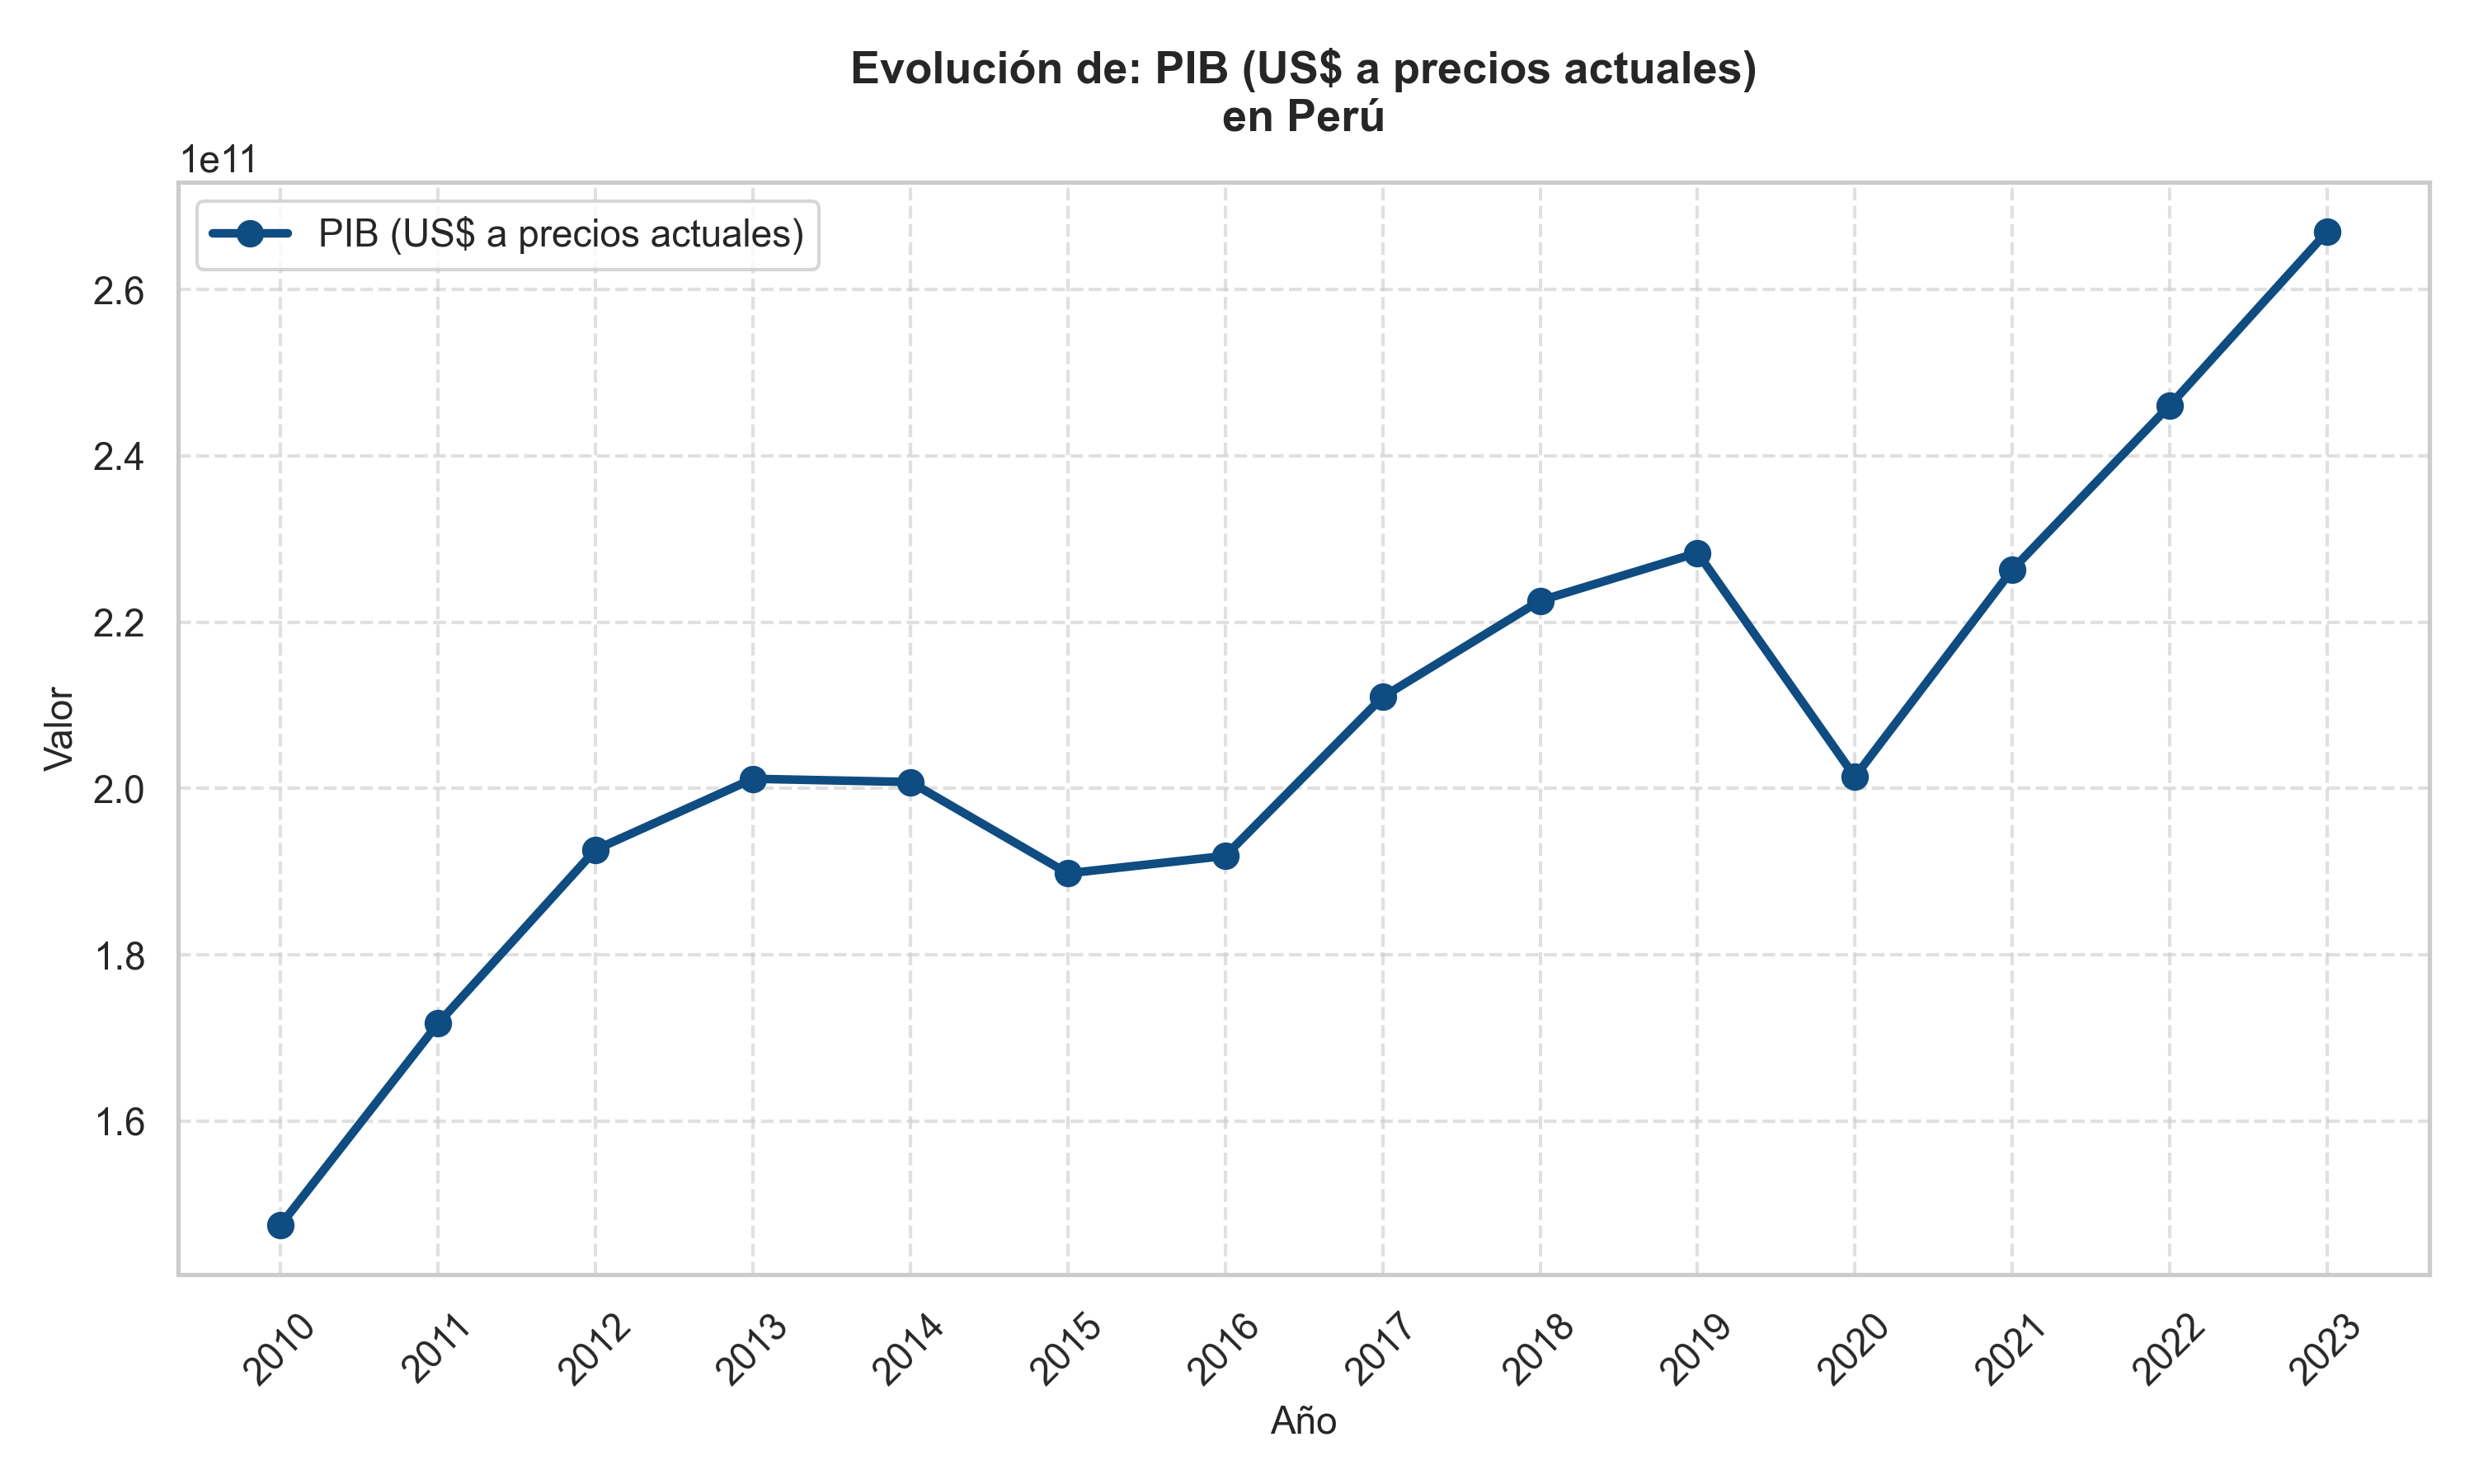


2. Comparativa de Tasas de Inflación en el año 2022 (Barras)


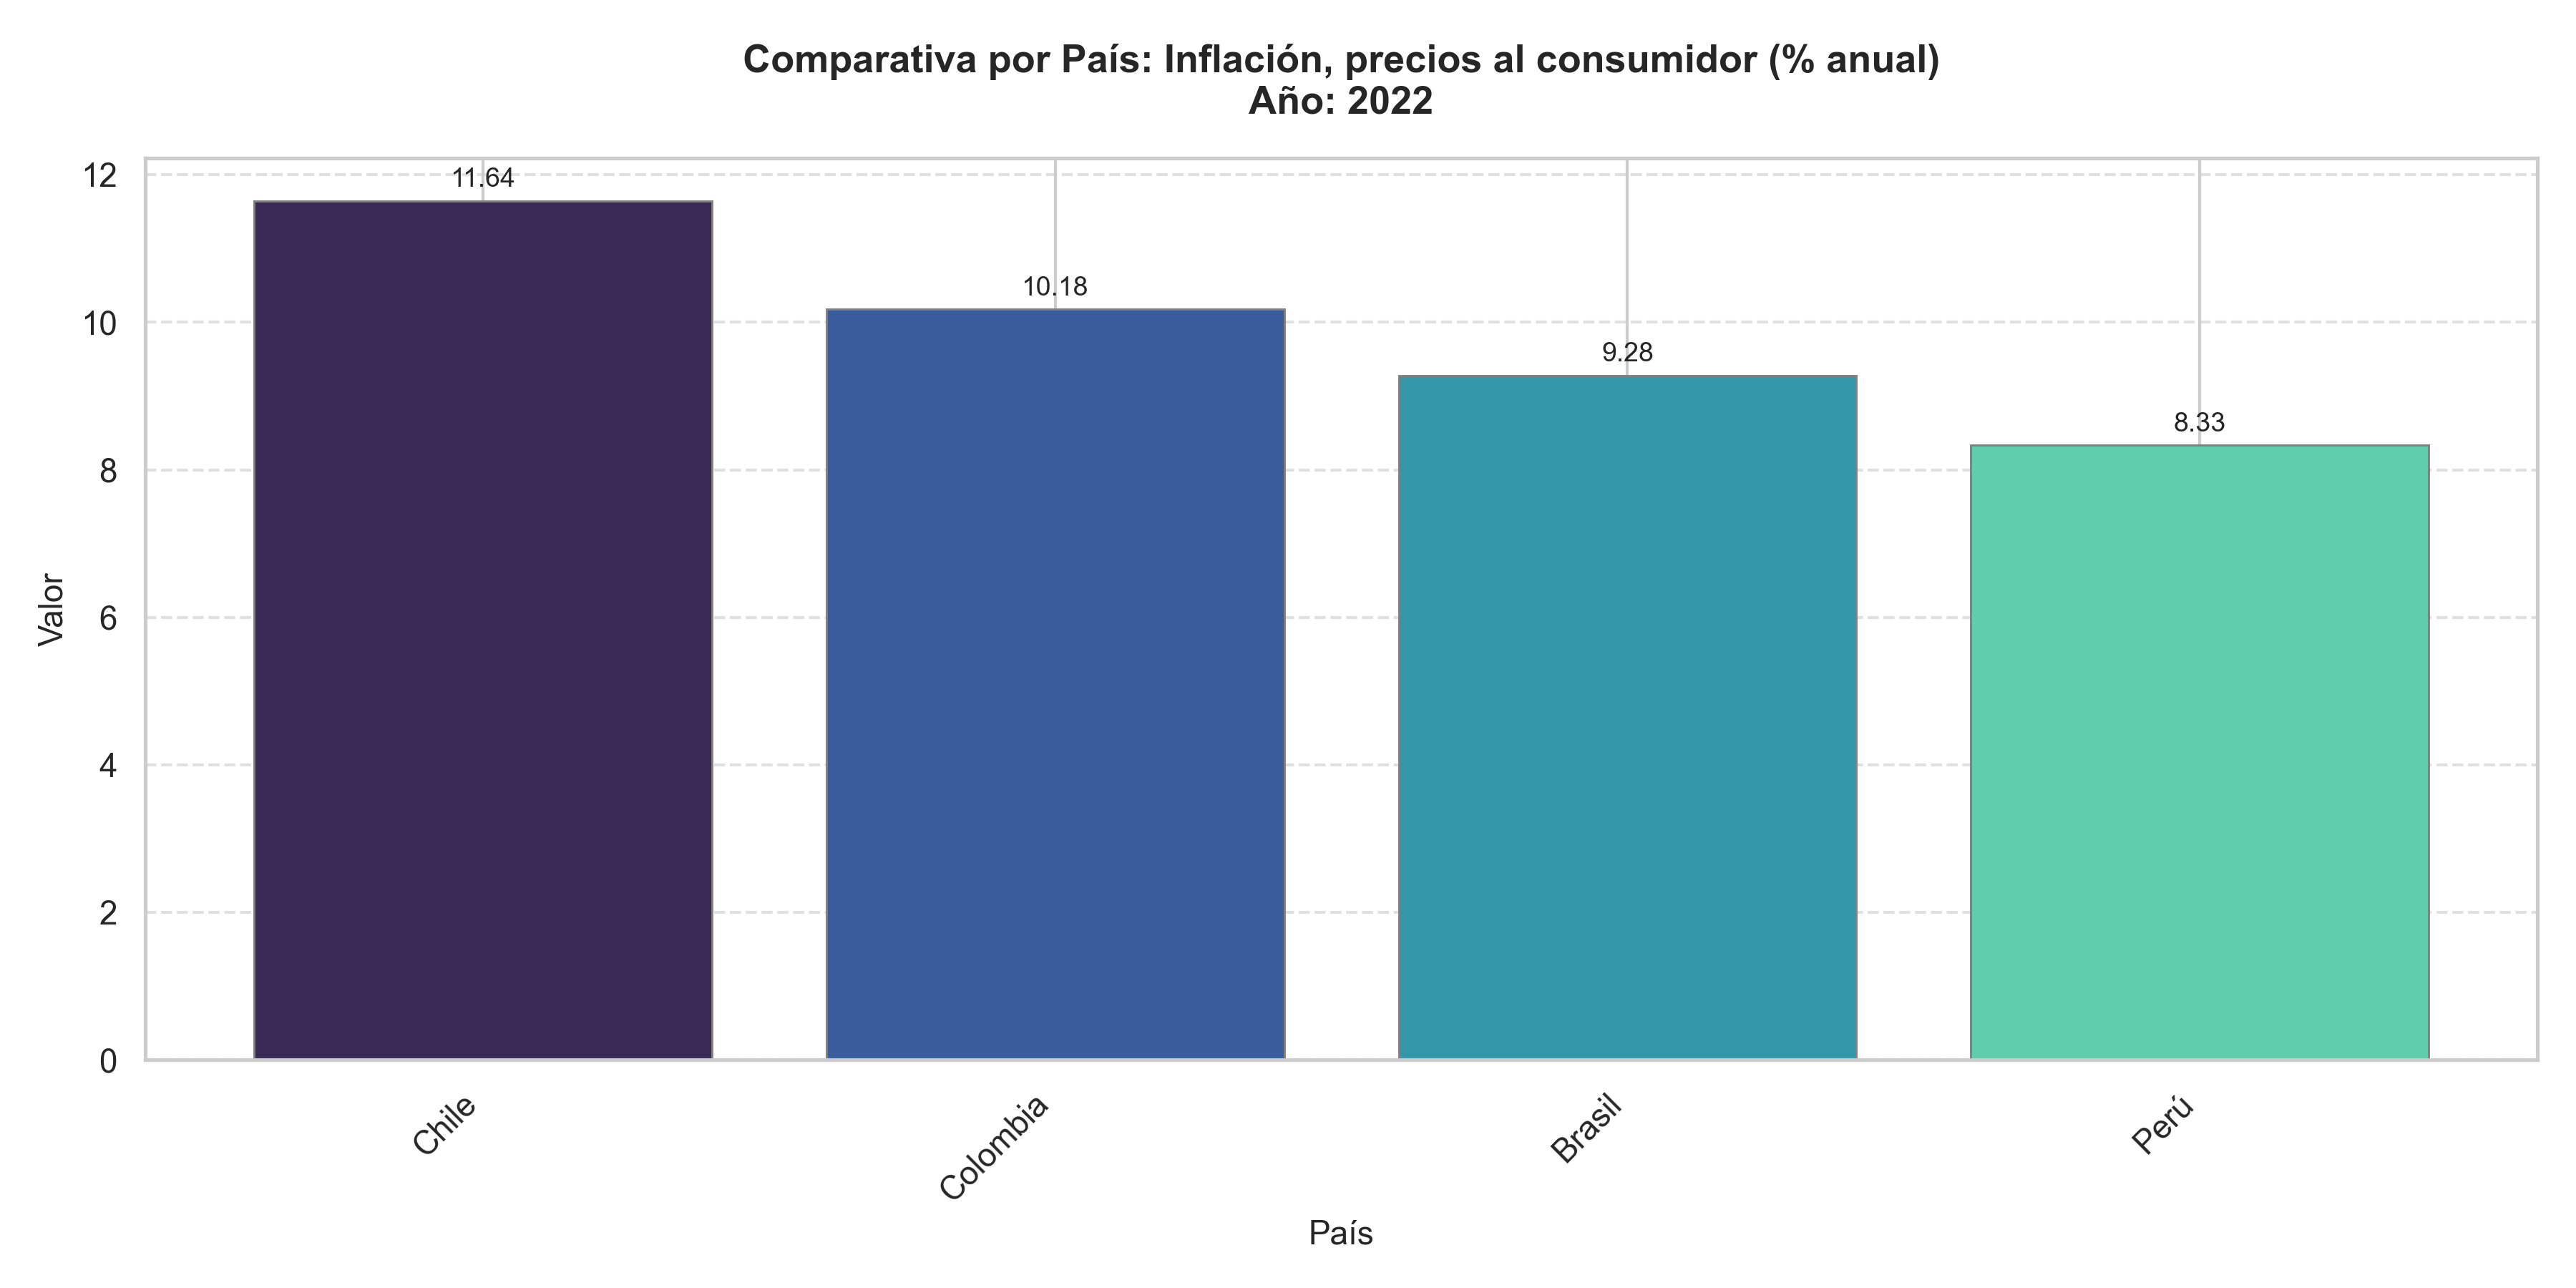


3. Relación entre PIB e Inflación en el año 2022 (Dispersión)


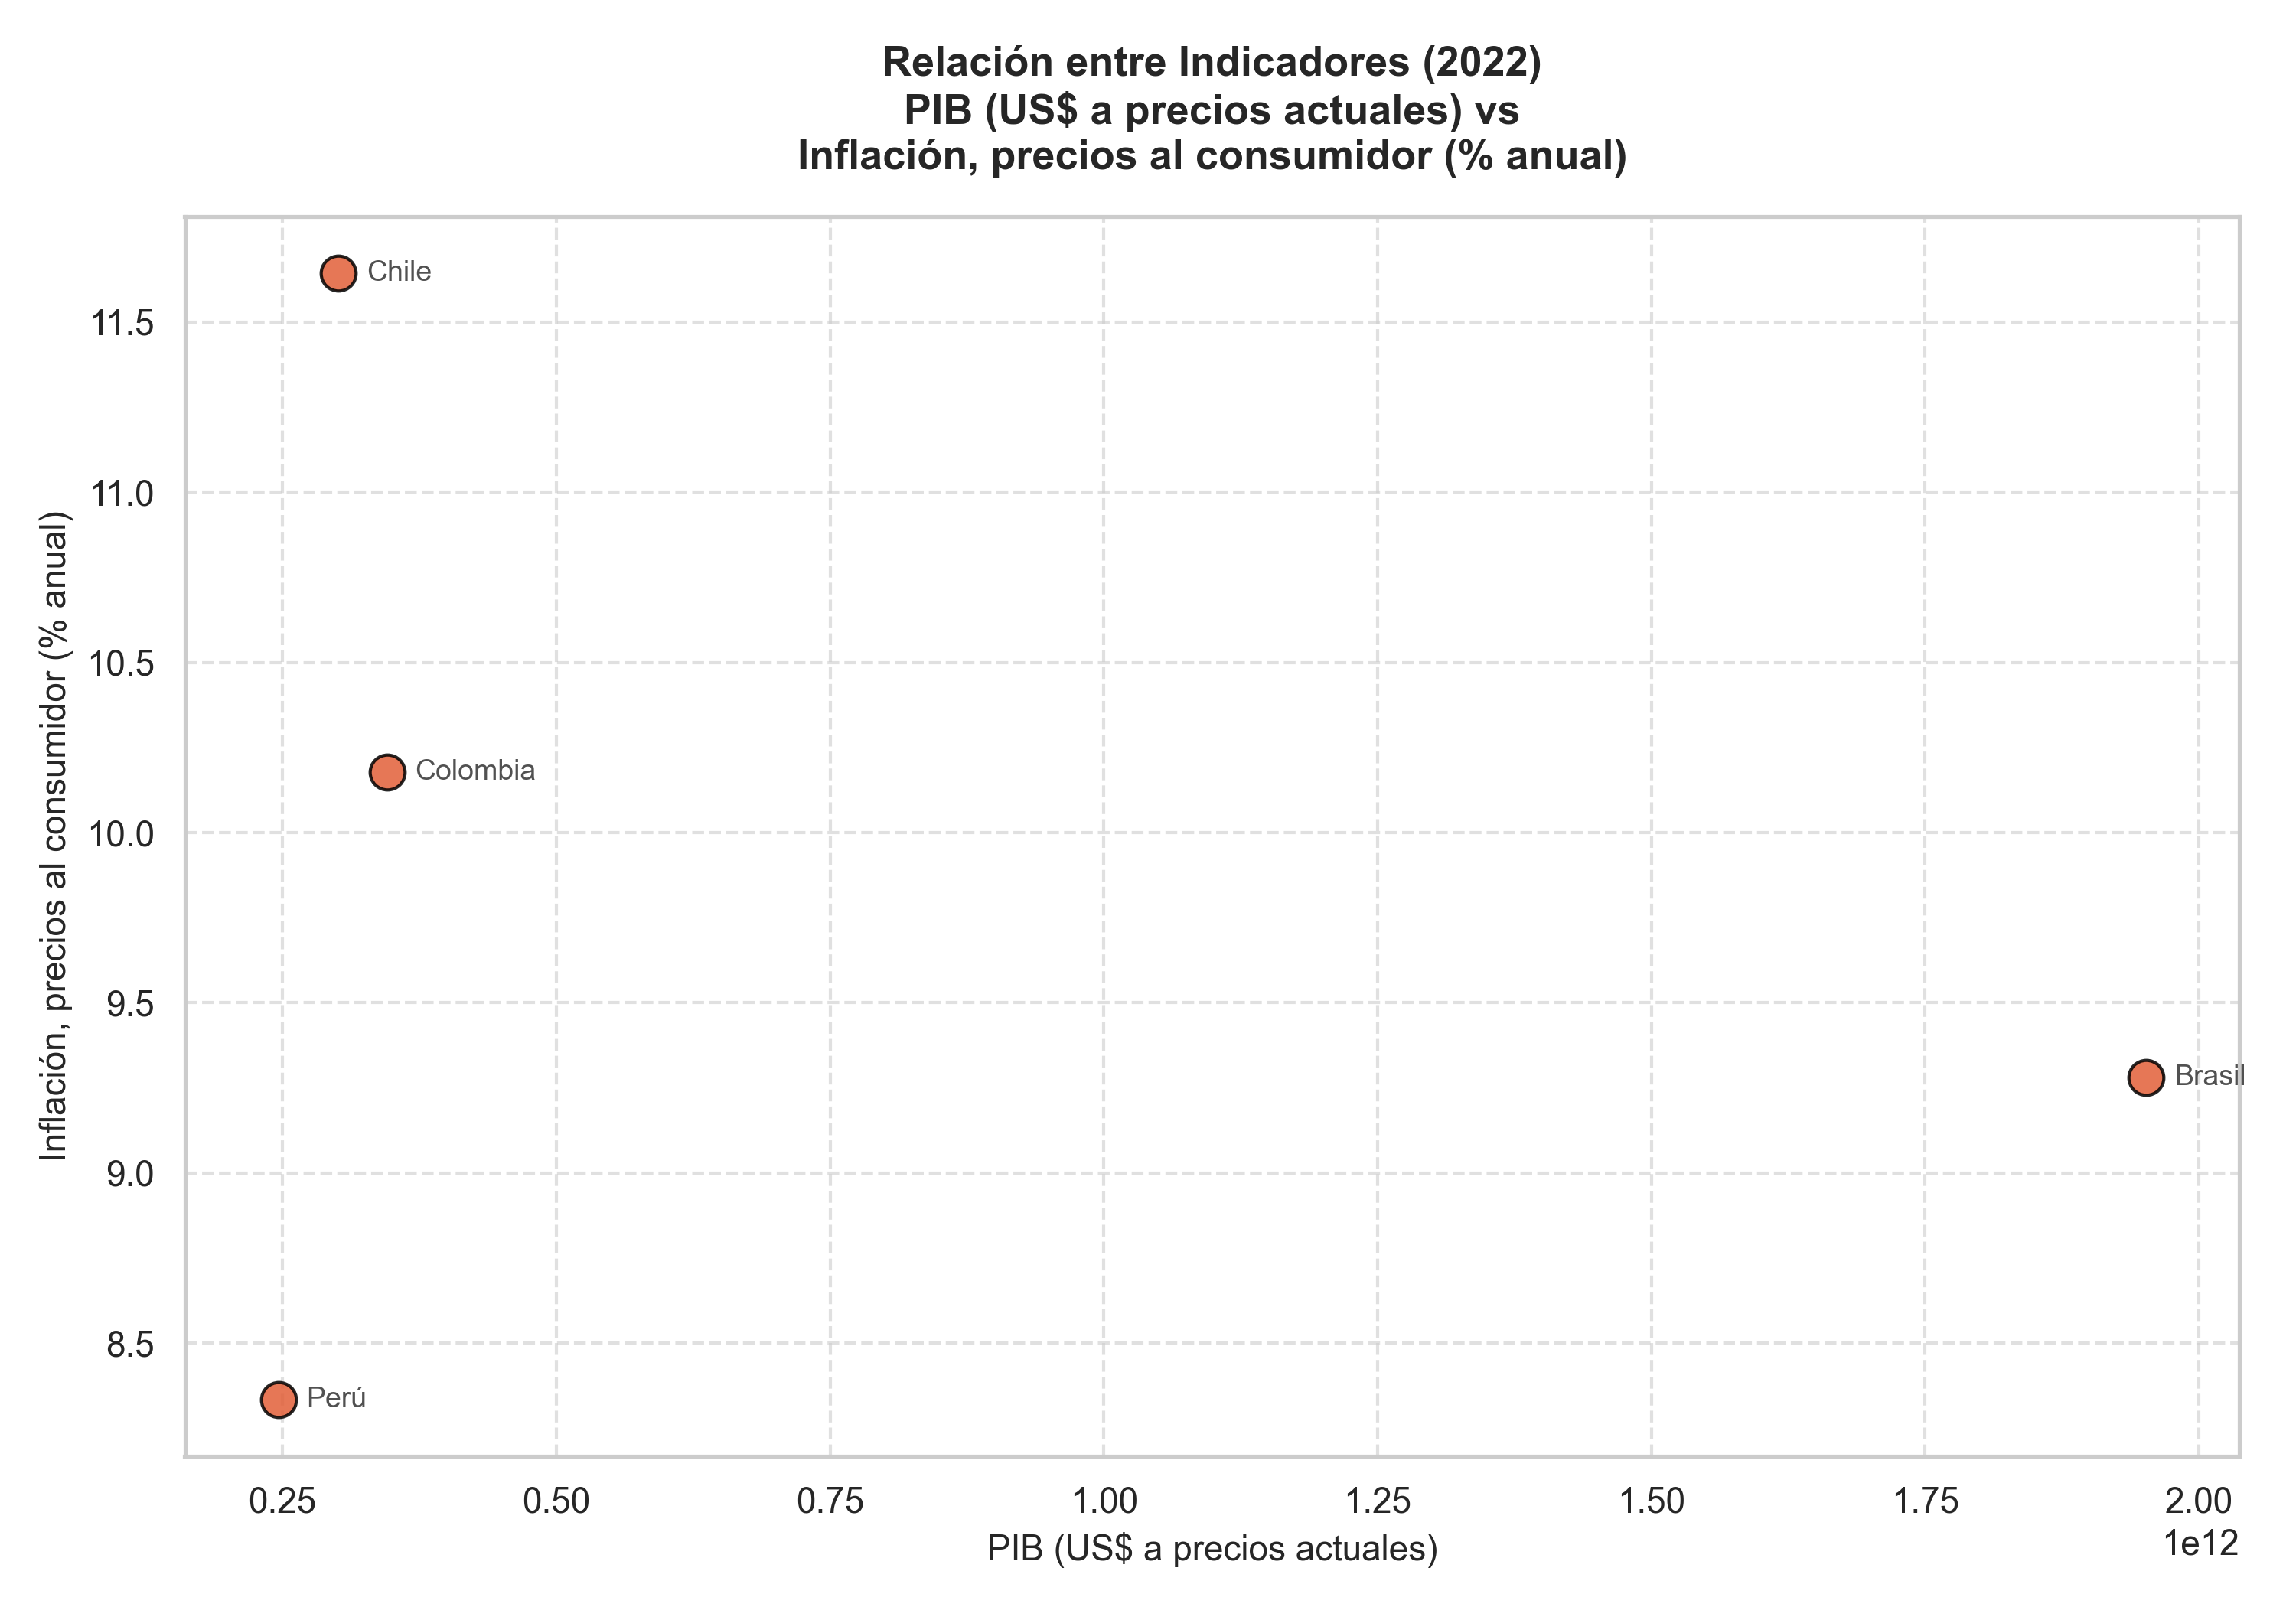


4. Distribución de Categorías de Inflación en el año 2022 (Pastel)


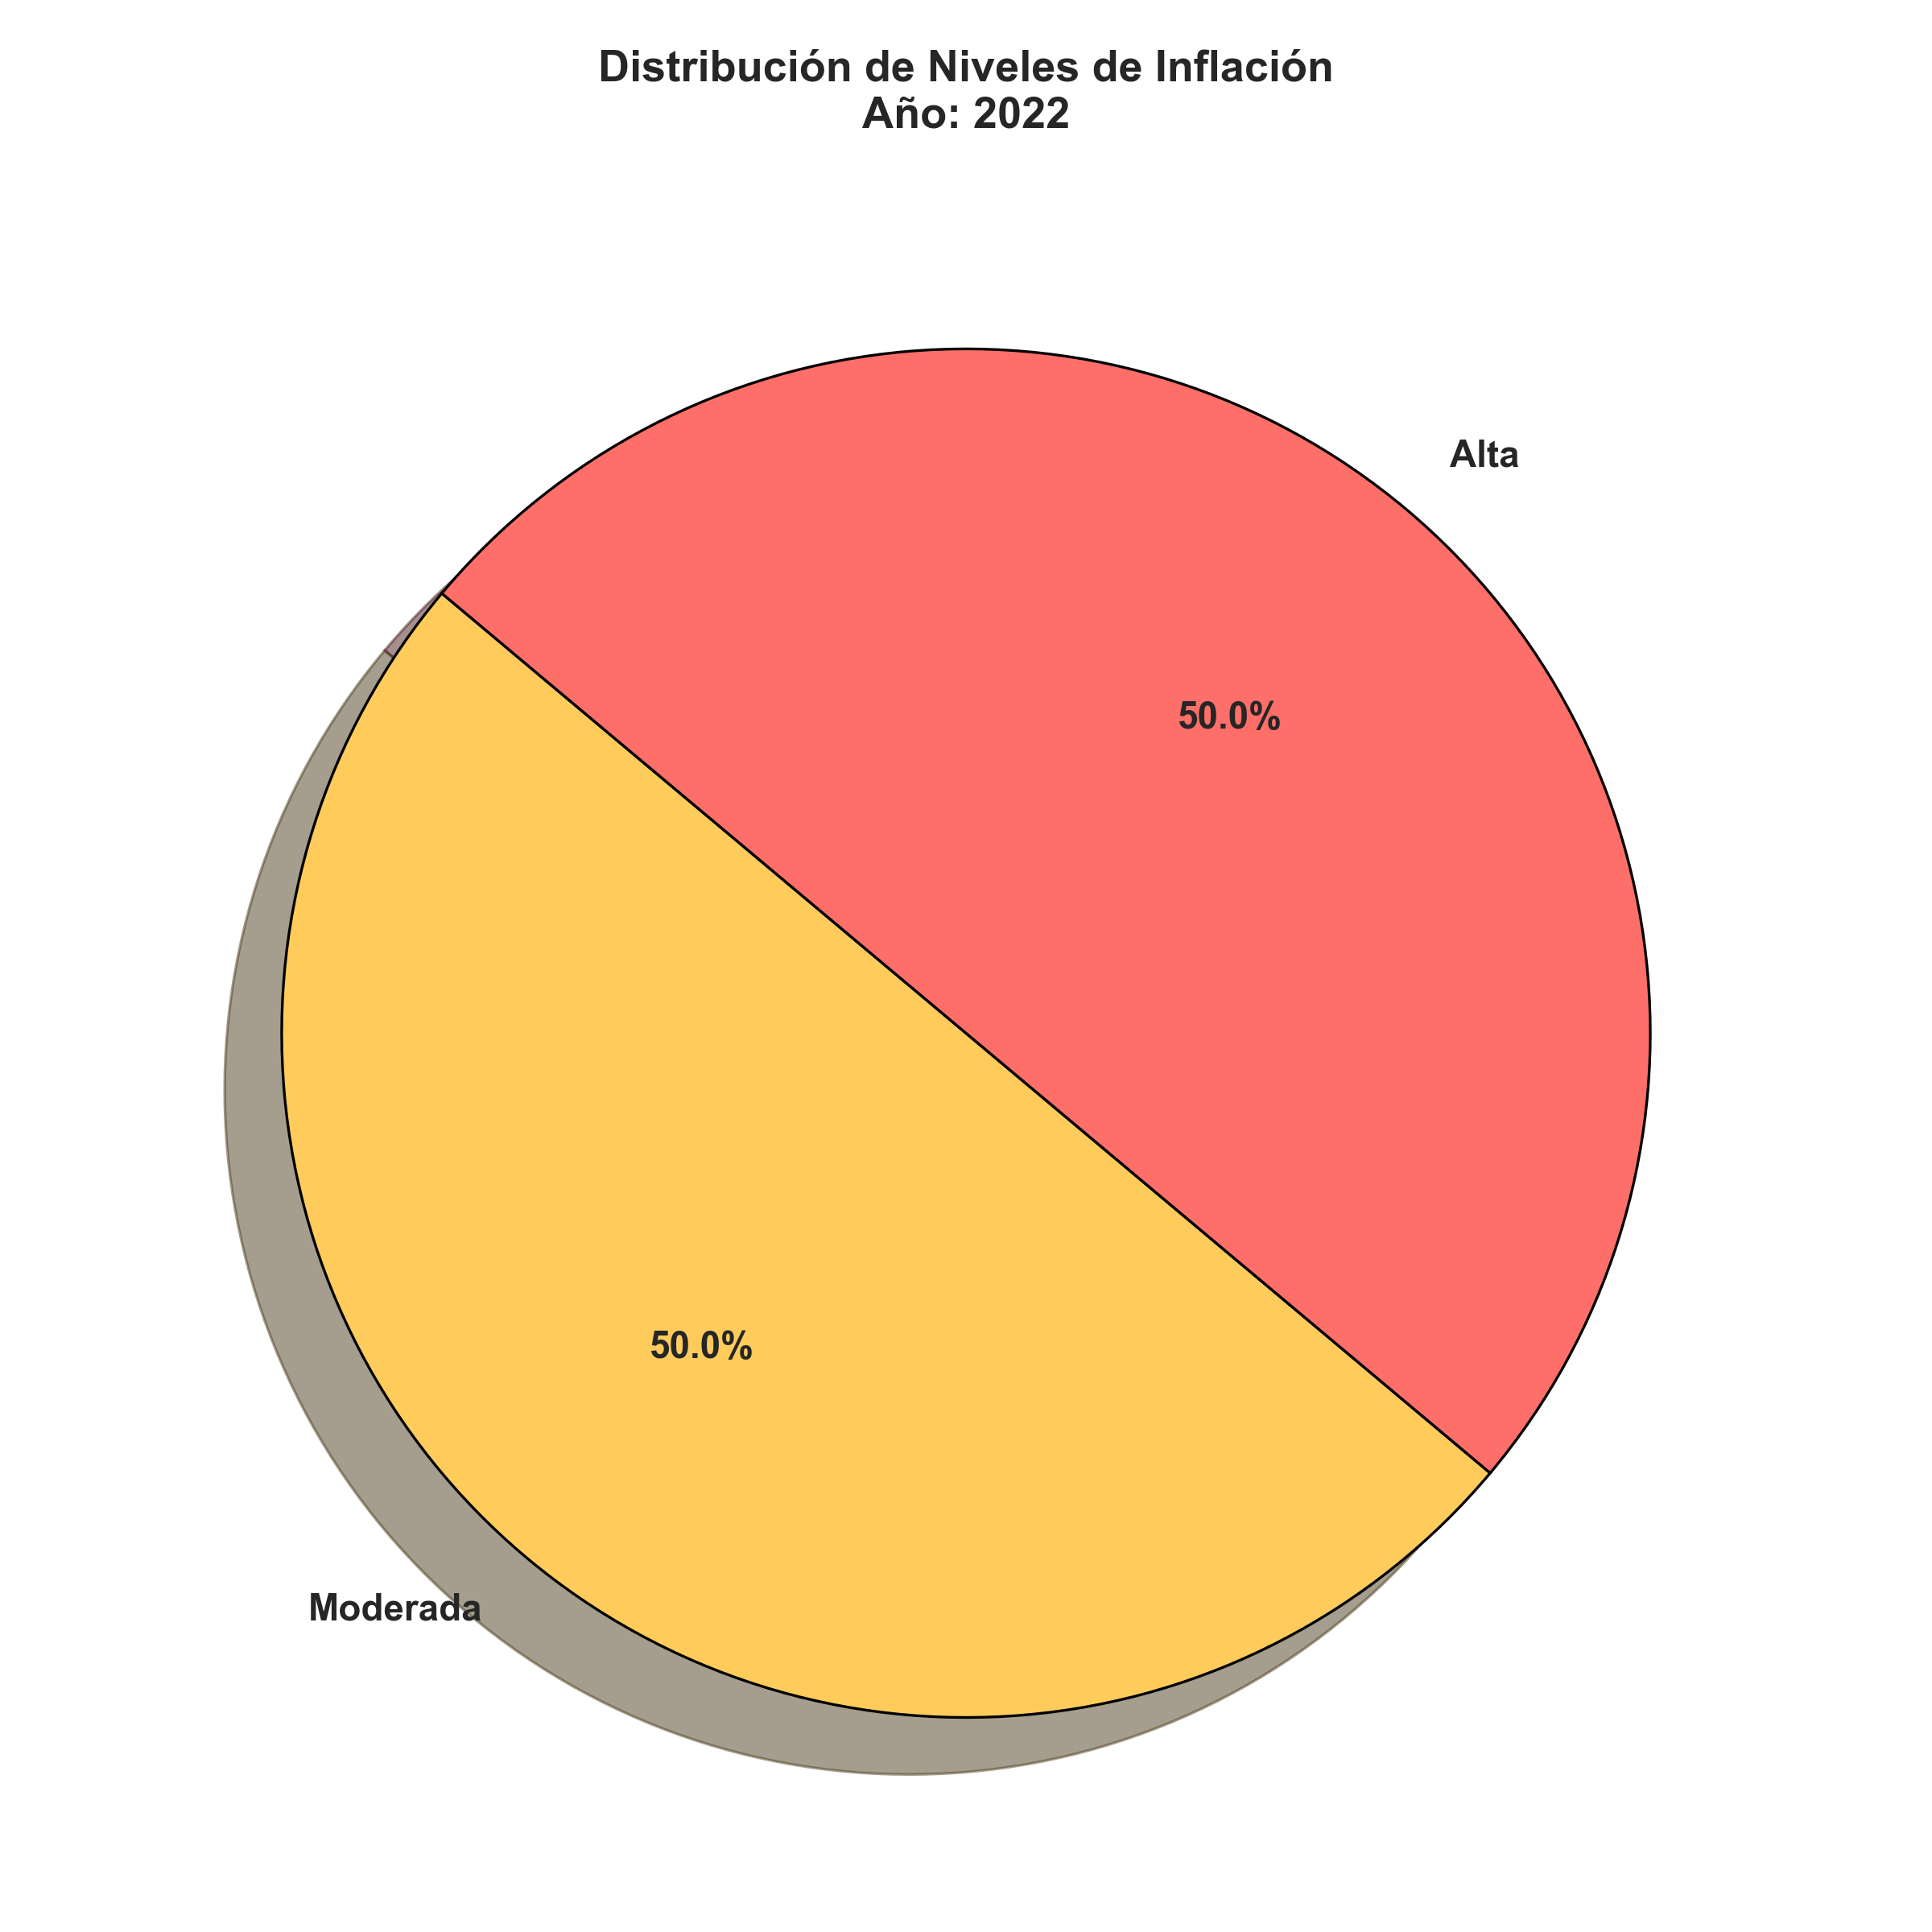

In [6]:
from IPython.display import Image, display

print("1. Evolución del PIB en el Perú (Líneas)")
if os.path.exists(ruta_lineas):
    display(Image(filename=ruta_lineas))

print("\n2. Comparativa de Tasas de Inflación en el año 2022 (Barras)")
if os.path.exists(ruta_barras):
    display(Image(filename=ruta_barras))

print("\n3. Relación entre PIB e Inflación en el año 2022 (Dispersión)")
if os.path.exists(ruta_dispersion):
    display(Image(filename=ruta_dispersion))

print("\n4. Distribución de Categorías de Inflación en el año 2022 (Pastel)")
if ruta_pastel and os.path.exists(ruta_pastel):
    display(Image(filename=ruta_pastel))

## 6. Conclusiones

- **Evolución Temporal**: El PIB en Perú ha mantenido una tendencia ascendente general entre 2010 y 2023, con una caída puntual y posterior recuperación rápida alrededor del año 2020 (impacto global).
- **Comparativa**: Durante el 2022, las tasas de inflación variaron significativamente entre los países analizados, reflejando el impacto de distintas políticas monetarias internas ante crisis globales.
- **Correlación**: El diagrama de dispersión ayuda a contextualizar que el tamaño nominal de las economías (PIB) no determina de manera directa la tasa de inflación anual.
- **Distribución de Precios**: El gráfico de pastel segmenta visualmente el estado de las economías bajo estudio en categorías de inflación baja, moderada y alta, lo cual simplifica la toma de decisiones analíticas.